# Homework 1: Linear Regression with Gradient Descent

**Student name:** Govind Menon
**Student ID:** 801371478


Use this notebook to write your code, run your experiments, show your plots, and answer the written questions.


## Academic Integrity / Submission Reminder

Write your own implementation. Do **not** use built-in machine learning library functions for gradient descent or linear regression training. You may use NumPy, pandas, and matplotlib for data handling, numerical operations, and plotting.


## 1. Import Libraries


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load and Inspect the Dataset

The dataset file should be named `D3.csv` and should be in the same folder as this notebook. The first three columns are explanatory variables `X1`, `X2`, `X3`, and the fourth column is the target variable `Y`.


In [71]:
df = pd.read_csv("D3.csv")
df.head()

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


In [72]:
# Optional: inspect dataset shape, column names, and basic statistics
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.describe()


Shape: (100, 4)
Columns: ['X1', 'X2', 'X3', 'Y']


,X1,X2,X3,Y
count,100.000000,100.000000,100.000000,100.000000
mean,2.000000,2.000000,1.960000,1.851276
std,1.172181,1.172154,1.163005,2.774643
min,0.000000,0.070303,0.027879,-5.332455
25%,1.000000,0.979394,0.952121,0.527533
50%,2.000000,2.009697,1.949091,2.879003
75%,3.000000,3.040000,2.946061,3.925389
max,4.000000,3.949091,3.943030,5.545892


## 3. Helper Functions

Complete the functions below. Keep these steps separate:

1. Compute predictions
2. Compute cost
3. Compute gradients
4. Update parameters
5. Run the training loop


In [73]:
def add_bias_column(X_raw):
    """
    Convert X_raw to a 2D NumPy array (if 1D) and add the intercept column x0 = 1.

    Parameters
    ----------
    X_raw : array-like, shape (m,) or (m, n)

    Returns
    -------
    X : ndarray, shape (m, n + 1)
    """
    # ensure X_raw is 2D before column_stack
    if len(X_raw.shape) == 1:
        X_raw = X_raw.reshape(-1, 1)
    return np.column_stack((np.ones(X_raw.shape[0]), X_raw))

In [74]:
def predict(X, w):
    """Return model predictions for linear regression."""
    prediction = X @ w
    return prediction

In [75]:
def compute_cost(X, y, w):
    """
    Compute mean squared error cost:
        L(w) = (1 / (2m)) * sum((y_hat - y)^2)
    """
    m = len(y)
    y_hat = predict(X, w)
    return ((1 / (2*m)) * np.sum((y_hat - y) **2))

In [76]:
def compute_gradient(X, y, w):
    """Compute gradient of the cost function with respect to w."""
    m = len(y)
    y_hat = predict(X, w)

    gradient = (1/m) * X.T @ (y_hat - y)

    return gradient

In [77]:
def update_parameters(w, gradient, learning_rate):
    """Update w using the gradient descent update rule."""

    return (w - (learning_rate * gradient))

In [78]:
def train_linear_regression(X, y, learning_rate, iterations):
    """
    Train linear regression using gradient descent.

    Returns
    -------
    w : ndarray
        Final learned parameters.
    cost_history : ndarray
        Cost value at each iteration.
    """
    w = np.zeros(X.shape[1])
    cost = []

    for i in range(iterations):
        gradient = compute_gradient(X, y, w)

        w = w - (learning_rate * gradient)

        cost_i = compute_cost(X, y, w)
        cost.append(cost_i)
    
    return w, np.array(cost)

## 4. Plotting Helpers


In [79]:
def plot_regression_fit(X_feature, y, w, feature_name):
    """
    Plot training data and the final fitted regression line
    for one-feature linear regression.
    """
    X_feature = np.asarray(X_feature).reshape(-1, 1)
    y = np.asarray(y).flatten()
    plt.figure(figsize=(7, 5))

    # Plot original training data points
    plt.scatter(X_feature.flatten(), y, label="Training data")

    # Sort feature values so the regression line tracks sequentially
    sorted_indices = np.argsort(X_feature.flatten())
    X_sorted = X_feature.flatten()[sorted_indices].reshape(-1, 1)

    # Add bias column and predict
    X_sorted_with_bias = add_bias_column(X_sorted)
    y_pred_sorted = predict(X_sorted_with_bias, w)

    
    plt.plot(X_sorted.flatten(), y_pred_sorted.flatten(), linewidth=2, label="Regression line")

    plt.xlabel(feature_name)
    plt.ylabel("Y")
    plt.title(f"Linear Regression Fit using {feature_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_cost_history(cost_history, title):
    """
    Plot cost/loss over iterations.
    """
    plt.figure(figsize=(7, 5))
    plt.plot(cost_history, linewidth=2)
    plt.xlabel("Iteration")
    plt.ylabel("Cost L(w)")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Problem 1: One Explanatory Variable at a Time

Run three separate linear regression trainings:

- `X1` only
- `X2` only
- `X3` only

Try multiple learning rates between `0.1` and `0.01`. Initialize w to zero for every training run.


In [80]:
target_name = "Y"
feature_names = ["X1", "X2", "X3"]
learning_rates = [0.1, 0.05, 0.01]  # You may change or add values
iterations = 2000

y = df[target_name].values




In [81]:
problem1_results = []
for feature_name in feature_names:
    X_raw = df[[feature_name]].values
    X = add_bias_column(X_raw)

    for lr in learning_rates:
        w, cost_history = train_linear_regression(X, y, lr, iterations)

        # save feature_name, lr, w, final cost, and cost history
        problem1_results.append({ "Feature": feature_name, "Learning Rate": lr, "W": w,
                                 "Final Cost": cost_history[-1], "Cost History": cost_history})
        


In [82]:
# Convert Problem 1 results to a DataFrame and display them
# Example columns: Feature, Learning Rate, W, Final Cost

problem1_summary = pd.DataFrame([
    {
        "Feature": result["Feature"],
        "Learning Rate": result["Learning Rate"],
        "W": result["W"],
        "Final Cost": result["Final Cost"]
    }
    for result in problem1_results
])

problem1_summary


,Feature,Learning Rate,W,Final Cost
0,X1,0.10,"[5.927948918061593, -2.038336633650798]",0.984993
1,X1,0.05,"[5.927948916834288, -2.038336633173125]",0.984993
2,X1,0.01,"[5.858868600540575, -2.011450225172623]",0.985602
3,X2,0.10,"[0.7360604300947883, 0.5576076103326052]",3.599366
4,X2,0.05,"[0.7360604299999355, 0.5576076103695229]",3.599366
5,X2,0.01,"[0.7307249777814311, 0.5596842180080547]",3.599370
6,X3,0.10,"[2.871422103988201, -0.5204828843001038]",3.629451
7,X3,0.05,"[2.8714221035850644, -0.5204828841406656]",3.629451
8,X3,0.01,"[2.8419103807380304, -0.5088111654359635]",3.629564


In [83]:
best_problem1_results = problem1_summary.loc[
    problem1_summary.groupby("Feature")["Final Cost"].idxmin()
]

best_problem1_results

,Feature,Learning Rate,W,Final Cost
1,X1,0.05,"[5.927948916834288, -2.038336633173125]",0.984993
3,X2,0.10,"[0.7360604300947883, 0.5576076103326052]",3.599366
6,X3,0.10,"[2.871422103988201, -0.5204828843001038]",3.629451


In [84]:
lowest_cost_index = best_problem1_results["Final Cost"].idxmin()
lowest_cost_feature = best_problem1_results.loc[lowest_cost_index]

lowest_cost_feature

Feature                                               X1
Learning Rate                                       0.05
W                [5.927948916834288, -2.038336633173125]
Final Cost                                      0.984993
Name: 1, dtype: object

## Problem 1(a): Report the Linear Model for Each Explanatory Variable

Write your answer below (only the best result (i.e., minimum cost) for each variable).


**X1 model:** ŷ = w0 + w1X1 = TODO  
**X2 model:** ŷ = w0 + w1X2 = TODO  
**X3 model:** ŷ = w0 + w1X3 = TODO


## Problem 1(b): Plot Final Regression Model and Loss for Each Explanatory Variable


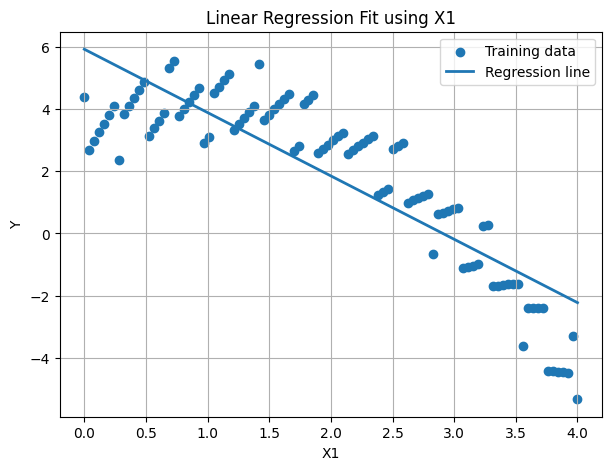

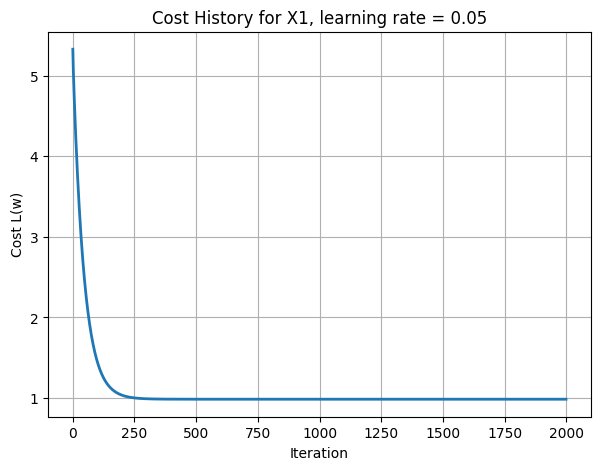

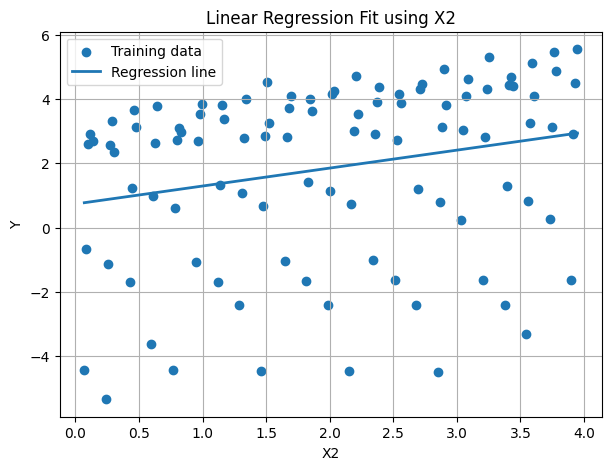

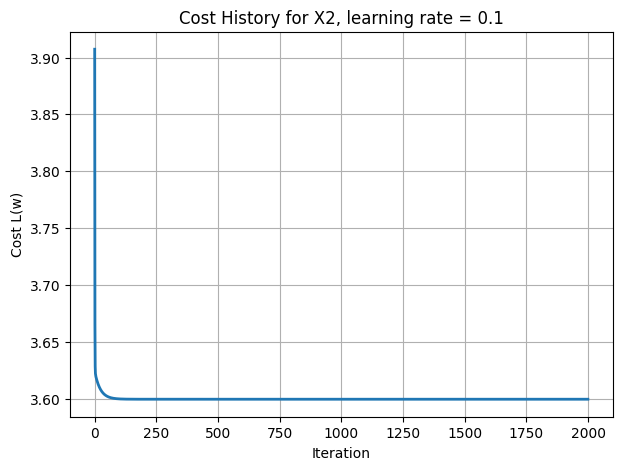

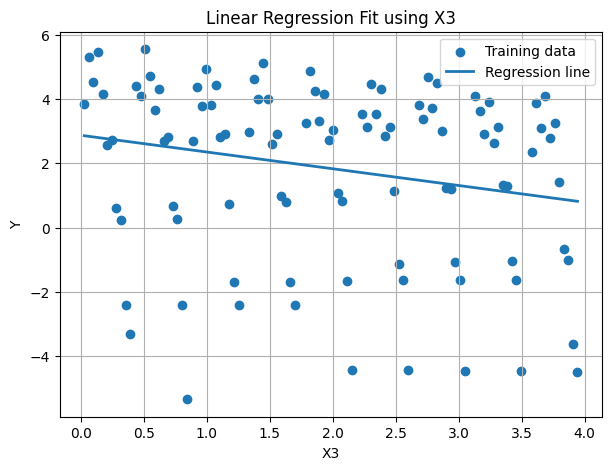

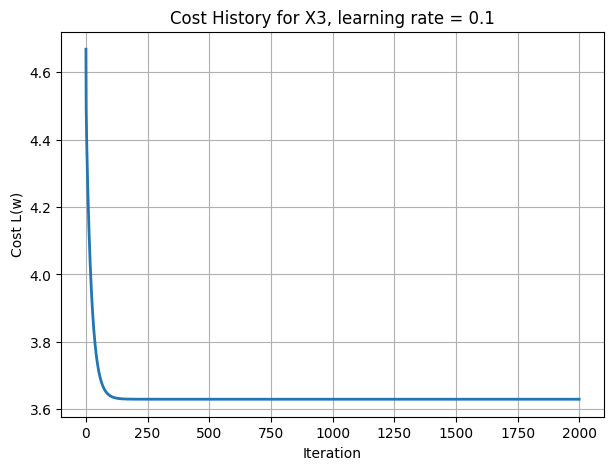

In [85]:
# TODO: For your selected/best learning rate for each feature, generate:
# 1. Regression fit plot
# 2. Cost/loss history plot
for feature_name in feature_names:
    # Find best result for this feature
    feature_results = [r for r in problem1_results if r["Feature"] == feature_name]
    best_result = min(feature_results, key=lambda r: r["Final Cost"])

    w = best_result["W"]
    cost_history = best_result["Cost History"]
    lr = best_result["Learning Rate"]

    X_raw = df[[feature_name]].values

    plot_regression_fit(X_raw, y, w, feature_name)
    plot_cost_history(cost_history, f"Cost History for {feature_name}, learning rate = {lr}")

## Problem 1(c): Which Explanatory Variable Has the Lowest Loss?

X1 with a learning rate of w = 0.05 has the lowest final loss


## Problem 1(d): Impact of Learning Rate

The learning rate for all 3 models affected convergence speed as the models with a higher learning rate, X2 and X3, converged faster at around 250 iterations while X1 converged at 300 iterations. For final loss, learning rate was not as influential as the scattered training data which made it harder for the model to find a good fit for X2 and X3 compared to X1.

# Problem 2: Linear Regression Using All Three Explanatory Variables

Train one model using `X1`, `X2`, and `X3` together. Try multiple learning rates between `0.1` and `0.01`. Initialize w to zero.


In [86]:
X_raw_all = df[["X1", "X2", "X3"]].values
X_all = add_bias_column(X_raw_all)
y = df["Y"].values

learning_rates = [0.1, 0.05, 0.01]  # You may change or add values
iterations = 2000




In [87]:
# TODO: Train using all three features for each learning rate
problem2_results = []
for lr in learning_rates:
    
    w, cost_history = train_linear_regression(X_all, y, lr, iterations)
    #  save lr, w, final cost, and cost history
    problem2_results.append({"Learning Rate": lr, "W": w, "Final Cost": cost_history[-1], 
                             "Cost History": cost_history})
   


In [88]:
# Convert Problem 2 results to a DataFrame and display them
# Example columns: Learning Rate, W, Final Cost
problem2_summary = pd.DataFrame([
    {
        "Learning Rate": result["Learning Rate"],
        "W": result["W"],
        "Final Cost": result["Final Cost"]
    }
    for result in problem2_results
])

problem2_summary

,Learning Rate,W,Final Cost
0,0.10,"[5.314167162142103, -2.0037192673109296, 0.532...",0.738464
1,0.05,"[5.313929889799811, -2.0036857486659665, 0.532...",0.738464
2,0.01,"[4.607841318597603, -1.9039390529021227, 0.649...",0.765039


In [89]:
best_index = problem2_summary["Final Cost"].idxmin()
best_w = problem2_summary.loc[best_index, "W"]
best_lr = problem2_summary.loc[best_index, "Learning Rate"]
best_cost = problem2_summary.loc[best_index, "Final Cost"]

print("Best learning rate:", best_lr)
print("Best w:", best_w)
print("Best final cost:", best_cost)

Best learning rate: 0.1
Best w: [ 5.31416716 -2.00371927  0.53256334 -0.26560186]
Best final cost: 0.7384642415682942


## Problem 2(a): Report the Best Final Linear Model

TODO: Write the best model in the form:

$\hat{y} = w_0 + w_1 X_1 + w_2 X_2 + w_3 X_3$


## Problem 2(b): Plot Loss Over Iteration


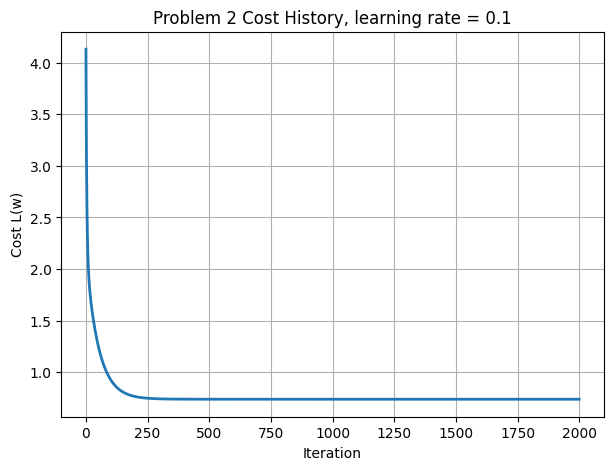

In [90]:
best_result_p2 = problem2_results[best_index]
best_cost_history = best_result_p2["Cost History"]

plot_cost_history(
    best_cost_history,
    f"Problem 2 Cost History, learning rate = {best_lr}"
)

## Problem 2(c): Impact of Learning Rate

TODO: Write a brief conclusion about how the learning rate affected convergence behavior for the multi-variable model. Provide the detailed explanation and supporting figures in the separate report PDF.


## Problem 2(d): Predictions for New Inputs

Predict `Y` for:

1. `(X1, X2, X3) = (1, 1, 1)`
2. `(X1, X2, X3) = (2, 0, 4)`
3. `(X1, X2, X3) = (3, 2, 1)`


In [91]:
new_examples = np.array([
    [1, 1, 1],
    [2, 0, 4],
    [3, 2, 1]
])

new_examples_with_bias = add_bias_column(new_examples)
predictions = predict(new_examples_with_bias, best_w)


prediction_table = pd.DataFrame(new_examples, columns=["X1", "X2", "X3"])
prediction_table["Predicted Y"] = predictions

prediction_table

,X1,X2,X3,Predicted Y
0,1,1,1,3.577409
1,2,0,4,0.244321
2,3,2,1,0.102534


# Final Checklist Before Submission

- [ ] Completed Jupyter Notebook file (.ipynb)
- [ ] PDF version of the completed notebook, including code, outputs, results, and plots
- [ ] Separate report PDF explaining the effect of learning rate and number of iterations
- [ ] Report includes name and student ID